# Fraud Model Walkthrough — Batch & Single-Transaction Scoring, SHAP, PDP/ICE, and Warm Start

This notebook exercises the pipeline end to end using the modules in this project:

- `feature_engineering.py` → `FraudFeatureEngineer`
- `models.py` → `FraudModelBundle`
- `explainability.py` → `FraudModelExplainer` (SHAP, feature importance, PDP/ICE)
- `fraud_pipeline.py` → `FraudDetectionPipeline` (single-transaction, stateful, real-time path)
- `batch_predictor.py` → `FraudBatchPredictor` (dict / list / DataFrame / CSV / Excel batch path)
- `input_handler.py` / `train_and_save_models.py`

**Before running:** make sure `models/feature_engineer.pkl`, `models/fraud_detector.joblib`,
`models/scenario_detector.joblib`, and `models/fraud_threshold.joblib` already exist
(run `python train_and_save_models.py --data-dir data --out-dir models` once if not),
and that `shap` is installed (`pip install shap`).


## 0. Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the project modules are importable (run this notebook from the
# project root, i.e. the same directory as feature_engineering.py etc.)
PROJECT_ROOT = Path(r"D:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System")

# Add the scripts directory to Python's search path
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_DIR = "models"
DATA_DIR = "data"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Load the fitted artifacts

Both `FraudDetectionPipeline` (single-tx, stateful) and `FraudBatchPredictor` (batch) load the
*same* `feature_engineer.pkl` + model bundle. In production you'd typically only use one of
them per process; here we load both side-by-side purely so this notebook can demo both paths.

In [2]:
from fraud_pipeline import FraudDetectionPipeline
from batch_predictor import FraudBatchPredictor

pipeline = FraudDetectionPipeline.from_artifacts(ARTIFACTS_DIR)
predictor = FraudBatchPredictor.from_artifacts(ARTIFACTS_DIR)

print("Fraud model loaded:", pipeline.model_bundle.fraud_model is not None)
print("Scenario model loaded:", pipeline.model_bundle.scenario_model is not None)
print("Explainer loaded:", pipeline.explainer is not None)


d:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-10 18:41:24,123 [INFO] Loaded feature engineer and model bundle from models
2026-07-10 18:41:25,436 [INFO] Explainability (SHAP / feature importance / PDP-ICE) ready.
2026-07-10 18:41:25,547 [INFO] Loaded feature engineer and model bundle from models
2026-07-10 18:41:26,618 [INFO] Explainability (SHAP / feature importance / PDP-ICE) ready.


Fraud model loaded: True
Scenario model loaded: True
Explainer loaded: True


## 2. Single-transaction scoring (real-time path)

`FraudDetectionPipeline.process_transaction` is the entry point you'd wire into an API /
Kafka consumer. Each call:
1. engineers features for the one transaction,
2. scores fraud probability + (informationally) the scenario model,
3. optionally updates that customer's realtime lag/velocity state,
4. optionally returns a SHAP explanation dict alongside the prediction.

In [3]:
new_tx = {
    "TRANSACTION_ID": 900001,
    "CUSTOMER_ID": 42,       # must exist in customer_profiles.csv
    "TERMINAL_ID": 917,      # must exist in terminal_profiles.csv
    "TX_DATETIME": "2026-07-05 02:14:00",
    "TX_AMOUNT": 110.50,
}

prediction = pipeline.process_transaction(new_tx, update_state=False)  # False so we can re-run this cell freely
prediction.to_dict()


{'TRANSACTION_ID': 900001,
 'fraud_probability': 0.218556,
 'is_fraud': False,
 'scenario_id': None,
 'scenario_name': None,
 'scenario_confidence': None}

### 2a. Same call, with a SHAP explanation attached

In [4]:
prediction, explanation = pipeline.process_transaction(new_tx, update_state=False, explain=True)

print("Prediction:")
print(json.dumps(prediction.to_dict(), indent=2))

print("\nTop 8 SHAP contributions (fraud model), sorted by |impact|:")
fraud_shap = {k: v for k, v in explanation.items() if k.startswith("shap_fraud_")}
top = sorted(fraud_shap.items(), key=lambda kv: abs(kv[1]), reverse=True)[:8]
for feat, val in top:
    print(f"  {feat:40s} {val:+.4f}")

scenario_shap = {k: v for k, v in explanation.items() if k.startswith("shap_scenario_")}
if scenario_shap:
    print("\nTop 8 SHAP contributions (scenario model, for the predicted scenario):")
    top_s = sorted(scenario_shap.items(), key=lambda kv: abs(kv[1]), reverse=True)[:8]
    for feat, val in top_s:
        print(f"  {feat:40s} {val:+.4f}")


Prediction:
{
  "TRANSACTION_ID": 900001,
  "fraud_probability": 0.218556,
  "is_fraud": false,
  "scenario_id": null,
  "scenario_name": null,
  "scenario_confidence": null
}

Top 8 SHAP contributions (fraud model), sorted by |impact|:
  shap_fraud_Z_score                       +1.1129
  shap_fraud_neigh_fraud_rate              +0.5548
  shap_fraud_distance                      -0.2258
  shap_fraud_TX_AMOUNT                     +0.1443
  shap_fraud_nb_terminals                  +0.1114
  shap_fraud_peer_group_amount_ratio       +0.0711
  shap_fraud_ratio_to_lag3                 -0.0693
  shap_fraud_terminal_fraud_rate_7d        -0.0543


d:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. Batch scoring — every supported input shape

`FraudBatchPredictor.predict` accepts a dict, a list of dicts, a DataFrame, or a CSV/Excel
path — all normalized through `input_handler.TransactionInputLoader`. By default it also
attaches `shap_fraud_<feature>` (and `shap_scenario_<feature>`) columns for every row.

In [5]:
# 3a. A single dict
res_dict = predictor.predict(new_tx, update_state=False)
res_dict


d:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
2026-07-10 18:41:46,268 [INFO] Scored 1/1 transaction(s) — 0 flagged as fraud, 0 failed to score.


,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_DATETIME,TX_AMOUNT,fraud_probability,is_fraud,scenario_id,scenario_name,scenario_confidence,scoring_error,shap_fraud_TX_AMOUNT,shap_fraud_hour,shap_fraud_distance,shap_fraud_Z_score,shap_fraud_amount_to_mean_ratio,shap_fraud_peer_group_amount_ratio,shap_fraud_is_night,shap_fraud_tx_count_1h,shap_fraud_tx_count_4h,shap_fraud_night_velocity,shap_fraud_terminal_fraud_rate_3d,shap_fraud_terminal_fraud_rate_7d,shap_fraud_terminal_fraud_rate_28d,shap_fraud_night_fraud_rate,shap_fraud_PREV_TX_AMOUNT_lag1,shap_fraud_PREV_TX_AMOUNT_lag2,shap_fraud_PREV_TX_AMOUNT_lag3,shap_fraud_ratio_to_lag1,shap_fraud_ratio_to_lag2,shap_fraud_ratio_to_lag3,shap_fraud_is_test_tx_sequence,shap_fraud_neigh_fraud_rate,shap_fraud_mean_nb_tx_per_day,shap_fraud_nb_terminals,shap_fraud_day_of_week,shap_scenario_TX_AMOUNT,shap_scenario_hour,shap_scenario_distance,shap_scenario_Z_score,shap_scenario_amount_to_mean_ratio,shap_scenario_peer_group_amount_ratio,shap_scenario_is_night,shap_scenario_tx_count_1h,shap_scenario_tx_count_4h,shap_scenario_night_velocity,shap_scenario_terminal_fraud_rate_3d,shap_scenario_terminal_fraud_rate_7d,shap_scenario_terminal_fraud_rate_28d,shap_scenario_night_fraud_rate,shap_scenario_PREV_TX_AMOUNT_lag1,shap_scenario_PREV_TX_AMOUNT_lag2,shap_scenario_PREV_TX_AMOUNT_lag3,shap_scenario_ratio_to_lag1,shap_scenario_ratio_to_lag2,shap_scenario_ratio_to_lag3,shap_scenario_is_test_tx_sequence,shap_scenario_neigh_fraud_rate,shap_scenario_mean_nb_tx_per_day,shap_scenario_nb_terminals,shap_scenario_day_of_week
0,900001,42,917,2026-07-05 02:14:00,110.5,0.218556,False,None,None,None,None,0.144306,-0.00612,-0.22577,1.112877,-0.00002,0.071051,0.0,-0.001951,0.003399,0.000934,-0.026711,-0.054339,-0.001158,0.0,-0.016866,0.007659,0.011606,0.01937,0.050134,-0.069287,0.0,0.554798,0.052574,0.111394,0.009906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# 3b. A list of dicts (multiple transactions, same or different customers)
batch = [
    {"TRANSACTION_ID": 900002, "CUSTOMER_ID": 42, "TERMINAL_ID": 917,
     "TX_DATETIME": "2026-07-05 02:14:00", "TX_AMOUNT": 189.50},
    {"TRANSACTION_ID": 900003, "CUSTOMER_ID": 42, "TERMINAL_ID": 12,
     "TX_DATETIME": "2026-07-05 02:20:00", "TX_AMOUNT": 5.00},
    {"TRANSACTION_ID": 900004, "CUSTOMER_ID": 7,  "TERMINAL_ID": 300,
     "TX_DATETIME": "2026-07-05 14:05:00", "TX_AMOUNT": 42.10},
]
res_list = predictor.predict(batch, update_state=False)
res_list[["TRANSACTION_ID", "CUSTOMER_ID", "fraud_probability", "is_fraud",
          "scenario_id", "scenario_name", "scenario_confidence"]]


d:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
2026-07-10 18:41:49,734 [INFO] Scored 3/3 transaction(s) — 0 flagged as fraud, 0 failed to score.


,TRANSACTION_ID,CUSTOMER_ID,fraud_probability,is_fraud,scenario_id,scenario_name,scenario_confidence
0,900002,42,0.965834,False,None,None,None
1,900003,42,0.021650,False,None,None,None
2,900004,7,0.045308,False,None,None,None


In [7]:
# 3c. A plain DataFrame (e.g. pulled from a warehouse query)
batch_df = pd.DataFrame(batch)
res_df = predictor.predict(batch_df, update_state=False)
res_df.filter(like="shap_fraud_").head()


d:\ITI Materials\Projects\Real_Time_Fraud_Transaction_System\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
2026-07-10 18:41:56,371 [INFO] Scored 3/3 transaction(s) — 0 flagged as fraud, 0 failed to score.


,shap_fraud_TX_AMOUNT,shap_fraud_hour,shap_fraud_distance,shap_fraud_Z_score,shap_fraud_amount_to_mean_ratio,shap_fraud_peer_group_amount_ratio,shap_fraud_is_night,shap_fraud_tx_count_1h,shap_fraud_tx_count_4h,shap_fraud_night_velocity,shap_fraud_terminal_fraud_rate_3d,shap_fraud_terminal_fraud_rate_7d,shap_fraud_terminal_fraud_rate_28d,shap_fraud_night_fraud_rate,shap_fraud_PREV_TX_AMOUNT_lag1,shap_fraud_PREV_TX_AMOUNT_lag2,shap_fraud_PREV_TX_AMOUNT_lag3,shap_fraud_ratio_to_lag1,shap_fraud_ratio_to_lag2,shap_fraud_ratio_to_lag3,shap_fraud_is_test_tx_sequence,shap_fraud_neigh_fraud_rate,shap_fraud_mean_nb_tx_per_day,shap_fraud_nb_terminals,shap_fraud_day_of_week
0,0.010787,0.052511,-0.158024,6.098856,-0.000018,-0.125628,0.0,-0.002851,-0.000247,0.000935,-0.019096,-0.037070,-0.004013,0.0,-0.059499,-0.027887,-0.004431,0.036236,0.138322,0.088217,0.0,0.316607,-0.042962,0.091390,0.011514
1,0.031514,-0.044667,-0.025766,-0.677857,0.000576,-0.170489,0.0,0.007998,-0.000166,0.000936,-0.023454,-0.051241,-0.003598,0.0,-0.138645,-0.037553,-0.012342,0.145026,0.308315,0.348561,0.0,-0.021824,-0.504301,0.101385,-0.021358
2,-0.014209,0.037070,-0.234556,0.056429,-0.000033,0.008598,0.0,0.007884,0.001697,0.000923,-0.024594,-0.053735,-0.006403,0.0,-0.067765,-0.004150,0.004647,0.120393,0.238715,-0.009100,0.0,-0.035979,0.024533,-0.079636,0.003256


In [ ]:
# 3d. A CSV file on disk
csv_path = Path("new_transactions_demo.csv")
pd.DataFrame(batch).to_csv(csv_path, index=False)

res_csv = predictor.predict(csv_path, update_state=False)
res_csv[["TRANSACTION_ID", "fraud_probability", "is_fraud"]]


In [ ]:
# 3e. Score + save straight to a file in one call
scored_out_path = Path("scored_demo.xlsx")
res_saved = predictor.predict_and_save(csv_path, scored_out_path, update_state=False)
print("Saved to:", scored_out_path.resolve())
res_saved.head()

## 4. Global feature importance (gain-based)

Independent of any single `predict()` call — a ranking of which engineered features the
model relies on most overall.

In [11]:
fraud_importance = predictor.get_feature_importance(model="fraud", importance_type="gain")
fraud_importance.head(15)


,feature,importance
0,Z_score,7.646425e+06
1,terminal_fraud_rate_7d,6.987655e+06
2,terminal_fraud_rate_3d,3.997902e+05
3,PREV_TX_AMOUNT_lag3,1.966198e+05
4,peer_group_amount_ratio,1.588188e+05
5,ratio_to_lag3,1.570840e+05
6,PREV_TX_AMOUNT_lag1,1.541652e+05
7,TX_AMOUNT,1.539646e+05
8,ratio_to_lag1,1.520578e+05
9,ratio_to_lag2,1.412688e+05


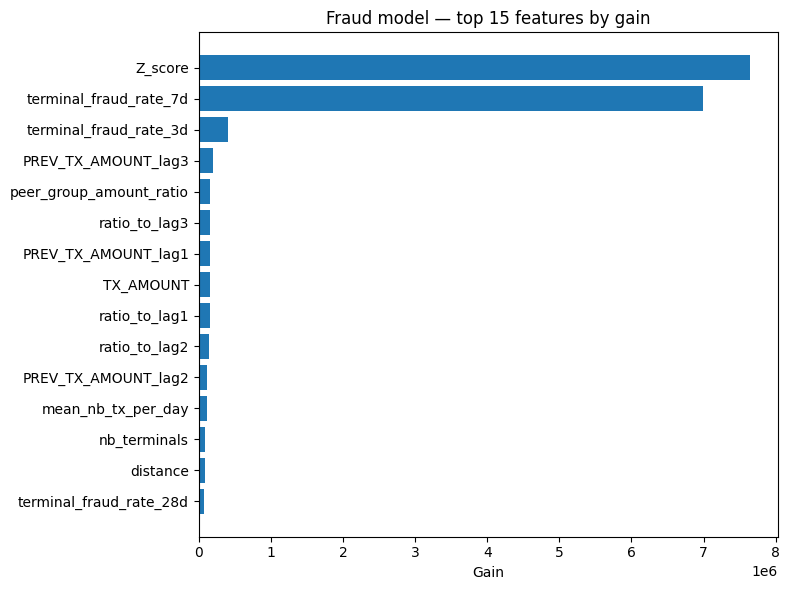

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
top_n = fraud_importance.head(15).iloc[::-1]
ax.barh(top_n["feature"], top_n["importance"])
ax.set_xlabel("Gain")
ax.set_title("Fraud model — top 15 features by gain")
plt.tight_layout()
plt.show()


In [13]:
if predictor.model_bundle.scenario_model is not None:
    scenario_importance = predictor.get_feature_importance(model="scenario", importance_type="gain")
    display(scenario_importance.head(15))
else:
    print("No scenario model loaded — skipping.")


,feature,importance
0,Z_score,140044.597596
1,TX_AMOUNT,22858.951037
2,terminal_fraud_rate_7d,13012.892375
3,terminal_fraud_rate_28d,2040.312426
4,PREV_TX_AMOUNT_lag3,1648.458537
5,PREV_TX_AMOUNT_lag2,1613.615005
6,ratio_to_lag2,1465.645141
7,ratio_to_lag1,1415.467473
8,PREV_TX_AMOUNT_lag1,1262.226535
9,ratio_to_lag3,1113.358110


## 5. Partial Dependence (PDP) + Individual Conditional Expectation (ICE)

`compute_partial_dependence` needs a reference sample of already-engineered rows. If you
don't pass one explicitly, it reuses the engineered features from the **most recent**
`predict()` call — so we run a representative batch through `predict()` first.

In [14]:
# Use a bigger, more representative batch as the PDP/ICE reference sample.
# Replace this with a real sample pulled from your own data if you have one handy.
reference_batch = pd.DataFrame(batch * 10)  # small demo "batch" repeated; swap for real data
reference_batch["TRANSACTION_ID"] = range(len(reference_batch))
_ = predictor.predict(reference_batch, update_state=False, include_explanations=False)

pdp_ice = predictor.compute_partial_dependence("TX_AMOUNT", model="fraud", kind="both", grid_resolution=50)
list(pdp_ice.keys())


2026-07-10 18:06:45,287 [INFO] Scored 30/30 transaction(s) — 0 flagged as fraud, 0 failed to score.


['feature', 'grid_values', 'pdp', 'ice']

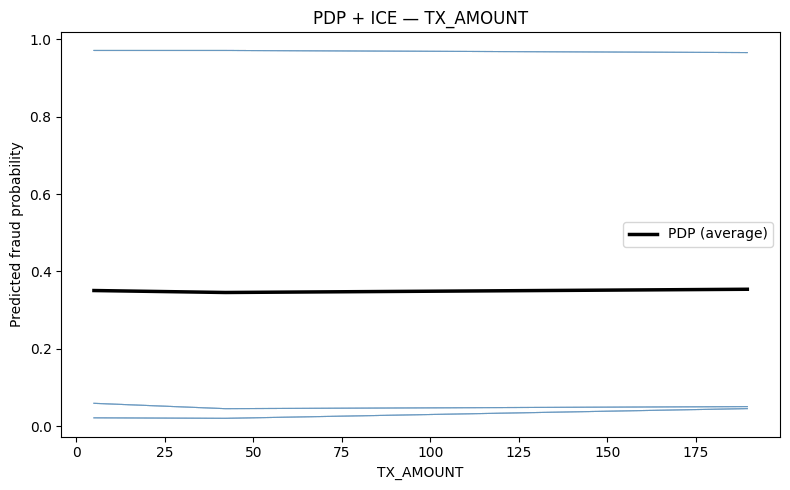

In [15]:
def plot_pdp_ice(result, ax=None, ice_alpha=0.15, max_ice_lines=100):
    ax = ax or plt.gca()
    grid = result["grid_values"]
    if "ice" in result:
        ice = result["ice"]
        for row in ice[:max_ice_lines]:
            ax.plot(grid, row, color="steelblue", alpha=ice_alpha, linewidth=0.8)
    if "pdp" in result:
        ax.plot(grid, result["pdp"], color="black", linewidth=2.5, label="PDP (average)")
    ax.set_xlabel(result["feature"])
    ax.set_ylabel("Predicted fraud probability")
    ax.set_title(f"PDP + ICE — {result['feature']}")
    ax.legend()
    return ax

fig, ax = plt.subplots(figsize=(8, 5))
plot_pdp_ice(pdp_ice, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
# A few more features at once
features_to_check = ["Z_score", "distance", "terminal_fraud_rate_7d"]
many = predictor.explainer.partial_dependence_many(features_to_check, predictor._last_scored_features,
                                                     model="fraud", kind="both", grid_resolution=50)

fig, axes = plt.subplots(1, len(features_to_check), figsize=(6 * len(features_to_check), 5))
for ax, feat in zip(axes, features_to_check):
    plot_pdp_ice(many[feat], ax=ax)
plt.tight_layout()
plt.show()


## 6. Warm start — verifying realtime state is seeded correctly

The lag (`PREV_TX_AMOUNT_lag1/2/3`) and velocity (`tx_count_1h`, `tx_count_4h`,
`night_velocity`) features depend on a customer's **realtime state**, which normally only
exists in memory after they've been scored earlier in this same process. A fresh process
(new deploy, restart, new replica) would otherwise silently cold-start every returning
customer — `warm_start_customer` / `warm_start_from_history` fix that by seeding state from
real history.

This section checks that warm start actually reproduces the same lag features you'd get
from actually having scored that history live.

In [16]:
# Pick a customer and fabricate (or load) their real recent transaction history.
# Swap this for a real slice pulled from your transactions table, e.g.:
#   history_df = pd.read_sql("SELECT TX_DATETIME, TX_AMOUNT FROM transactions WHERE CUSTOMER_ID = 42 ...", conn)
warm_customer_id = 42
history_df = pd.DataFrame({
    "TX_DATETIME": pd.to_datetime([
        "2026-07-05 00:10:00",
        "2026-07-05 00:45:00",
        "2026-07-05 01:30:00",
    ]),
    "TX_AMOUNT": [22.50, 61.00, 15.75],
})
history_df


,TX_DATETIME,TX_AMOUNT
0,2026-07-05 00:10:00,22.50
1,2026-07-05 00:45:00,61.00
2,2026-07-05 01:30:00,15.75


In [17]:
# --- Path A: cold start --------------------------------------------------
# A brand-new FraudFeatureEngineer/pipeline instance has NO memory of this
# customer's history yet, so their next transaction cold-starts (lag values
# fall back to the customer's profile mean_amount, velocity counts are 0).
cold_pipeline = FraudDetectionPipeline.from_artifacts(ARTIFACTS_DIR, load_explainer=False)

probe_tx = {
    "TRANSACTION_ID": 900010,
    "CUSTOMER_ID": warm_customer_id,
    "TERMINAL_ID": 917,
    "TX_DATETIME": "2026-07-05 02:00:00",
    "TX_AMOUNT": 50.0,
}

cold_features = cold_pipeline.feature_engineer.transform(probe_tx)
cold_features[["PREV_TX_AMOUNT_lag1", "PREV_TX_AMOUNT_lag2", "PREV_TX_AMOUNT_lag3",
               "tx_count_1h", "tx_count_4h", "night_velocity"]]


2026-07-10 18:07:36,395 [INFO] Loaded feature engineer and model bundle from models


,PREV_TX_AMOUNT_lag1,PREV_TX_AMOUNT_lag2,PREV_TX_AMOUNT_lag3,tx_count_1h,tx_count_4h,night_velocity
0,54.498478,54.498478,54.498478,0,0,0


In [18]:
# --- Path B: warm-started -------------------------------------------------
# Same fresh instance, but we warm-start this customer from their real history
# BEFORE scoring the same probe transaction.
warm_pipeline = FraudDetectionPipeline.from_artifacts(ARTIFACTS_DIR, load_explainer=False)
was_warmed = warm_pipeline.warm_start_customer(warm_customer_id, history_df)
print("warm_start_customer returned:", was_warmed)
print("is_warm(customer) before any live scoring:", warm_pipeline.is_warm(warm_customer_id))

warm_features = warm_pipeline.feature_engineer.transform(probe_tx)
warm_features[["PREV_TX_AMOUNT_lag1", "PREV_TX_AMOUNT_lag2", "PREV_TX_AMOUNT_lag3",
               "tx_count_1h", "tx_count_4h", "night_velocity"]]


2026-07-10 18:08:05,716 [INFO] Loaded feature engineer and model bundle from models
2026-07-10 18:08:05,720 [INFO] warm_start_customer(42): seeded from 3 historical row(s) (last_amounts=3, recent_tx_times=3).


warm_start_customer returned: True
is_warm(customer) before any live scoring: True


,PREV_TX_AMOUNT_lag1,PREV_TX_AMOUNT_lag2,PREV_TX_AMOUNT_lag3,tx_count_1h,tx_count_4h,night_velocity
0,15.75,61.0,22.5,1,3,1


In [19]:
# --- Path C: ground truth ---------------------------------------------------
# Actually replay the history through a fresh engine via register_realtime_state,
# then score the same probe transaction. This is the "no restart ever happened"
# baseline that warm start is trying to reproduce.
truth_pipeline = FraudDetectionPipeline.from_artifacts(ARTIFACTS_DIR, load_explainer=False)
for _, row in history_df.sort_values("TX_DATETIME").iterrows():
    hist_tx = {
        "CUSTOMER_ID": warm_customer_id,
        "TERMINAL_ID": 917,   # terminal doesn't affect lag/velocity, only used for risk lookups
        "TX_DATETIME": row["TX_DATETIME"],
        "TX_AMOUNT": row["TX_AMOUNT"],
    }
    truth_pipeline.feature_engineer.register_realtime_state(hist_tx)

truth_features = truth_pipeline.feature_engineer.transform(probe_tx)
truth_features[["PREV_TX_AMOUNT_lag1", "PREV_TX_AMOUNT_lag2", "PREV_TX_AMOUNT_lag3",
                "tx_count_1h", "tx_count_4h", "night_velocity"]]


2026-07-10 18:08:52,445 [INFO] Loaded feature engineer and model bundle from models


,PREV_TX_AMOUNT_lag1,PREV_TX_AMOUNT_lag2,PREV_TX_AMOUNT_lag3,tx_count_1h,tx_count_4h,night_velocity
0,15.75,61.0,22.5,1,3,1


In [20]:
# --- Compare ----------------------------------------------------------------
compare_cols = ["PREV_TX_AMOUNT_lag1", "PREV_TX_AMOUNT_lag2", "PREV_TX_AMOUNT_lag3",
                "tx_count_1h", "tx_count_4h", "night_velocity"]

comparison = pd.concat([
    cold_features[compare_cols].assign(path="cold_start"),
    warm_features[compare_cols].assign(path="warm_started"),
    truth_features[compare_cols].assign(path="ground_truth"),
]).set_index("path")
display(comparison)

matches = np.allclose(
    warm_features[compare_cols].values.astype(float),
    truth_features[compare_cols].values.astype(float),
)
print("\nwarm_started matches ground_truth exactly:", matches)
print("warm_started differs from cold_start:",
      not np.allclose(warm_features[compare_cols].values.astype(float),
                       cold_features[compare_cols].values.astype(float)))


,PREV_TX_AMOUNT_lag1,PREV_TX_AMOUNT_lag2,PREV_TX_AMOUNT_lag3,tx_count_1h,tx_count_4h,night_velocity
path,,,,,,
cold_start,54.498478,54.498478,54.498478,0,0,0
warm_started,15.750000,61.000000,22.500000,1,3,1
ground_truth,15.750000,61.000000,22.500000,1,3,1



warm_started matches ground_truth exactly: True
warm_started differs from cold_start: True


### 6a. Idempotency — warm-starting the same customer twice shouldn't double-count

In [21]:
warm_pipeline.warm_start_customer(warm_customer_id, history_df)  # call again
warm_features_2nd = warm_pipeline.feature_engineer.transform(probe_tx)

still_matches = np.allclose(
    warm_features_2nd[compare_cols].values.astype(float),
    warm_features[compare_cols].values.astype(float),
)
print("Re-warm-starting produced identical features (idempotent):", still_matches)


2026-07-10 18:09:41,727 [INFO] warm_start_customer(42): seeded from 3 historical row(s) (last_amounts=3, recent_tx_times=3).


Re-warm-starting produced identical features (idempotent): True


### 6b. Bulk warm start (`warm_start_from_history`)

The production-realistic pattern at process startup: warm every returning customer at once
from a recent slice of the transactions table, and get back a report of who was
warmed/skipped.

In [22]:
bulk_history = pd.concat([
    history_df.assign(CUSTOMER_ID=warm_customer_id),
    pd.DataFrame({
        "TX_DATETIME": pd.to_datetime(["2026-07-05 09:00:00", "2026-07-05 09:40:00"]),
        "TX_AMOUNT": [12.0, 88.0],
        "CUSTOMER_ID": 7,
    }),
    pd.DataFrame({  # an unknown customer, to show it's skipped gracefully
        "TX_DATETIME": pd.to_datetime(["2026-07-05 10:00:00"]),
        "TX_AMOUNT": [30.0],
        "CUSTOMER_ID": 999_999_999,
    }),
], ignore_index=True)

bulk_pipeline = FraudDetectionPipeline.from_artifacts(ARTIFACTS_DIR, load_explainer=False)
report = bulk_pipeline.warm_start_from_history(bulk_history)
report


2026-07-10 18:09:56,724 [INFO] Loaded feature engineer and model bundle from models
2026-07-10 18:09:56,730 [INFO] warm_start_customer(7): seeded from 2 historical row(s) (last_amounts=2, recent_tx_times=2).
2026-07-10 18:09:56,733 [INFO] warm_start_customer(42): seeded from 3 historical row(s) (last_amounts=3, recent_tx_times=3).
2026-07-10 18:09:56,734 [INFO] warm_start_from_history: warmed=2 skipped_unknown=1 skipped_empty=0 skipped_error=0


{'warmed': [7, 42],
 'skipped_unknown': [999999999],
 'skipped_empty': [],
 'skipped_error': []}

## 7. Persist accumulated realtime state

After live scoring with `update_state=True`, call `save_state` so a restart resumes warm
(this writes `feature_engineer.pkl` back out with the accumulated customer buffers).

In [ ]:
# Example only — uncomment to actually persist:
# predictor.save_state(ARTIFACTS_DIR)
# pipeline.save_state(ARTIFACTS_DIR)
print("Skipped by default so this demo notebook doesn't mutate your real artifacts.")
